## <strong>Getting started</strong>

The document that you are reading is not a static web page, but an interactive environment called a <strong>Colab notebook</strong> that lets you write and execute code.


First of all, let's mount our Google Drive on our runtime.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


With the Google Drive mounted, you can now store your image files (or any other file you wish, for that matter) in any directory of your choice in Drive, e.g.:

In [ ]:
images_dir = '/content/gdrive/My Drive/Teaching/2021-2022/AI2/SlidesLectureNotes'


## Motivation Example: balls in urns
Let us denote the proportion of black ball, or the probability of drawing a black ball as $\theta$, i.e.,$P(B) = \theta $ and $P(W) = 1- \theta $ for a white ball.

Since each draw is Independent and identically distributed (I.I.D), we can calculate the probability of getting that sequence $\mathbf{x}$ as the product of the probabilities of each of the individual draws:



$$
L(\theta|\mathbf{x}) = \prod_{i=1}^{N}  \begin{cases}
\theta \; & \text{ if } x_i = B \\
1-\theta \; & \text{ if } x_i = W \\  
\end{cases}
$$



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

D = 'BBWBWWBWWWBW'
idx = [pos for pos, char in enumerate(D) if char == 'B']
print(idx)
theta = 0.41 # black balls made up 5/12 of the urn
pp = np.array([1-theta] * len(D))
pp[np.array(idx)] = theta

print(pp)
totalprobability = np.prod(pp)
s = 'Probability of sequence with ' + repr(theta) + ' black ball distribution: ' + repr(totalprobability)
print(s)



[0, 1, 3, 6, 10]
[0.41 0.41 0.59 0.41 0.59 0.59 0.41 0.59 0.59 0.59 0.41 0.59]
Probability of sequence with 0.41 black ball distribution: np.float64(0.0002883257066441387)


## Graph the likelihood
we can easily abstract this as a function of and θ, and graph the likelihood as a function of any value of the proportion of black balls from 0 to 1:

Text(0, 0.5, 'Likelihood')

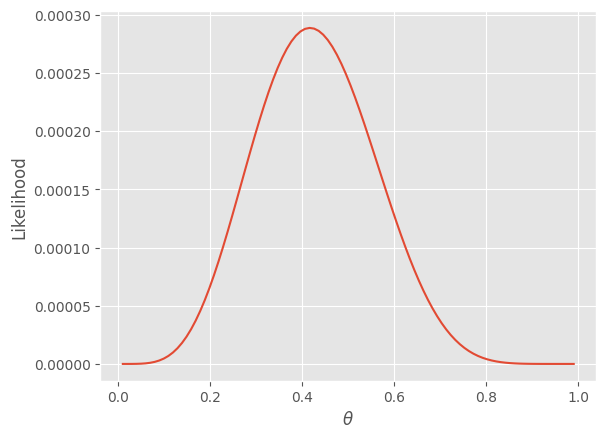

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

def totalprob(theta, D):
    idx = [pos for pos, char in enumerate(D) if char == 'B']
    pp = np.array([1-theta] * len(D))
    pp[np.array(idx)] = theta
    totalprobability = np.prod(pp)
    return totalprobability

D = 'BBWBWWBWWWBW'
seqlen = len(D)
x = np.linspace(.01, .99, 100)
likelihoods  = []
for theta in x:
  likelihoods = np.append(likelihoods, totalprob(theta, D))

# Plot the figure
handle = plt.figure()
plt.style.use(['ggplot'])
plt.plot(x, likelihoods)
plt.xlabel(r'$\theta$')
plt.ylabel('Likelihood')

#handle.savefig(f"{images_dir}/Week-8-Lecture-5-Optimisation-Gradient-Descent/Likelihood.pdf", bbox_inches='tight')


## Cost function

The cost function, also known as the loss function or objective function, is the function that optimization works over – we want to find the optimal set of events to minimize the “cost” of those events.

This is extremely general, but has a one-to-one mapping with likelihood: for parameter fitting the cost function is often calculated as the negative logarithm of the likelihood function:

$$
C(\theta, \mathbf{x}) = -\log(L(\theta|\mathbf{x}))
$$



/tmp/ipython-input-811680207.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


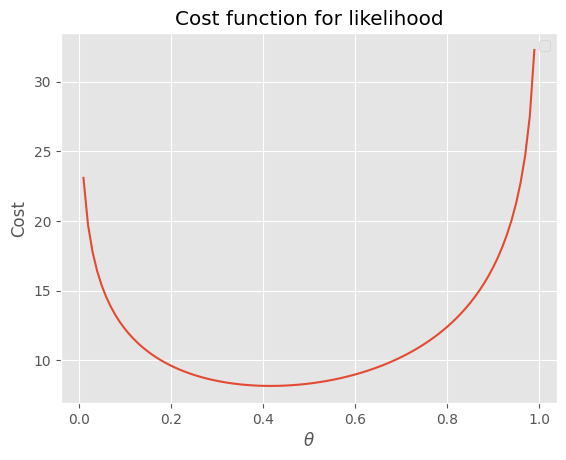

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

def cost(theta, D):
    idx = [pos for pos, char in enumerate(D) if char == 'B']
    pp = np.array([1-theta] * len(D))
    pp[np.array(idx)] = theta
    totalprobability = np.prod(pp)
    return -np.log(totalprobability)

D = 'BBWBWWBWWWBW'
seqlen = len(D)
x = np.linspace(.01, .99, 100)
likelihoods  = []
for theta in x:
  likelihoods = np.append(likelihoods, cost(theta, D))

# Plot the figure
handle = plt.figure()
plt.style.use(['ggplot'])
plt.plot(x, likelihoods)
plt.xlabel(r'$\theta$')
plt.ylabel('Cost')
plt.title('Cost function for likelihood')
plt.legend()
plt.show()

#handle.savefig(f"{images_dir}/Week-8-Lecture-5-Optimisation-Gradient-Descent/cost.pdf", bbox_inches='tight')

## Gradient descent
Gradient descent is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function.

To find a local minimum of a function using gradient descent, we start at any value of $\theta$, then change the parameter in the direction that decreases the cost function, and keep repeating until there is only the tiniest decrease in cost with each step.

The only math required is the gradient calculation, which needs differentiation of the cost function with respect to the independent variable $\theta$. However, you can use [Automatic differentiation](https://en.wikipedia.org/wiki/). For Python implementation, you can use Python's [autograd](https://github.com/HIPS/autograd) library.

/tmp/ipython-input-1657773047.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


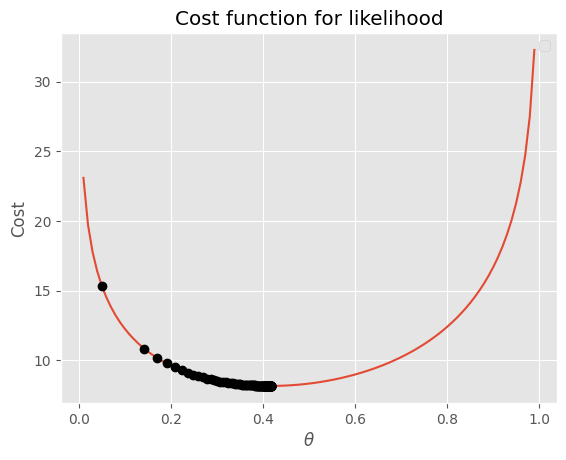

The local minimum occurs at 0.41664783101589214


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use(['ggplot'])

# If you are lazy, you can use Automatic differentiation
# See https://en.wikipedia.org/wiki/Automatic_differentiation
# You can use Python's autograd library: https://github.com/HIPS/autograd
def urn_gradient(theta):
  gradient = (7/(1-theta) - 5/theta)
  return gradient

def cost(theta, D):
    idx = [pos for pos, char in enumerate(D) if char == 'B']
    pp = np.array([1-theta] * len(D))
    pp[np.array(idx)] = theta
    totalprobability = np.prod(pp)
    return -np.log(totalprobability)

iterations = 100
D = 'BBWBWWBWWWBW'
seqlen = len(D)
x = np.linspace(.01, .99, 100)
likelihoods  = []
for theta in x:
  likelihoods = np.append(likelihoods, cost(theta, D))

# Plot the figure
handle = plt.figure()
plt.style.use(['ggplot'])
plt.plot(x, likelihoods)
plt.xlabel(r'$\theta$')
plt.ylabel('Cost')
plt.title('Cost function for likelihood')
plt.legend()


cur_theta = 0.05 # The algorithm starts at 0.05
eta = 0.001 # Learning rate
precision = 0.000001 #This tells us when to stop the algorithm
previous_step_size = 1 #
max_iters = 10000 # maximum number of iterations
iters = 0 #iteration counter

while previous_step_size > precision and iters < max_iters:
    currnt_cost = cost(cur_theta, D);
    plt.plot(cur_theta, currnt_cost, 'o', color='black')
    prev_theta = cur_theta #Store current x value in prev_x
    cur_theta = cur_theta - eta * urn_gradient(prev_theta) #Grad descent
    previous_step_size = abs(cur_theta - prev_theta) #Change in x
    iters = iters+1 #iteration count
    #print("Iteration",iters,"\nX value is",cur_theta) #Print iterations

plt.show()
print("The local minimum occurs at", cur_theta)




## Optimisation: an example
We follow the book *Mathematics for Machine Learning* (pp. 225) to plot a continous function which has a global minimum global minimum around x = −4.5, with a function value of approximately −47. Since the function is “smooth,” the gradients can be used to help find the minimum by indicating whether we should take a step to the right or left. This assumes that we are in the correct bowl, as there exists another local local minimum minimum around x = 0.7.

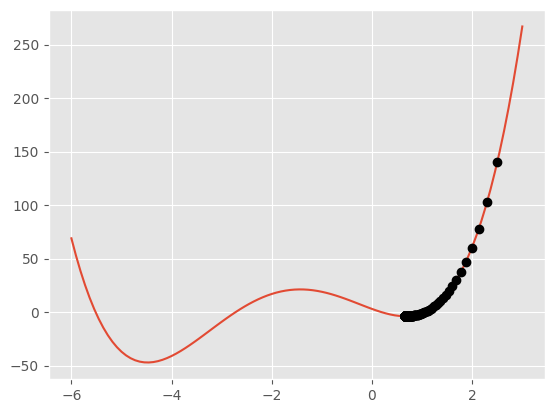

The local minimum occurs at 0.6624029117809244


In [ ]:
# Import matplotlib, numpy and math
import matplotlib.pyplot as plt
import numpy as np

# Define the continous function l(x)
def arbi_cost(theta):
  return theta**4 + 7*theta**3 + 5*theta**2 - 17*theta + 3

# Define the corresponding gradient
def arbi_gradient(theta):
    return 4*theta**3 + 21*theta**2 +  10*theta -17

grid_th = np.linspace(-6,3,100)

# Plot the figure
handle = plt.figure()
plt.plot(grid_th, arbi_cost(grid_th))

cur_theta = 2.5 # The algorithm starts at x=3
rate = 0.001 # Learning rate
precision = 0.000001 #This tells us when to stop the algorithm
previous_step_size = 1 #
max_iters = 10000 # maximum number of iterations
iters = 0 #iteration counter

while previous_step_size > precision and iters < max_iters:
    currnt_cost = arbi_cost(cur_theta);
    plt.plot(cur_theta, currnt_cost, 'o', color='black')
    prev_theta = cur_theta #Store current x value in prev_x
    cur_theta = cur_theta - rate * arbi_gradient(prev_theta) #Grad descent
    previous_step_size = abs(cur_theta - prev_theta) #Change in x
    iters = iters+1 #iteration count
    #print("Iteration",iters,"\nX value is",cur_theta, "\nCost value is", currnt_cost) #Print iterations

plt.show()
print("The local minimum occurs at", cur_theta)

#handle.savefig(f"{images_dir}/Week-2-Lecture-6-Single-Variable Optimisation/Figure72.pdf", bbox_inches='tight')

## Logistic Regression and Maximum Likelihood
In Lecture 2, we learned Logistic Regression. We use an example, time spent and passing Math exams to illustrate the idea of logistic regression. Here is an Python implementation using SciKit Learning. See [Scikit Learn document](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np


X_train = np.transpose(np.array([[ 4, 6, 10, 14, 4, 7, 12, 22, 3, 15]]))
y_train = np.array([0, 0, 1, 1, 0, 0, 1, 1, 0, 1])
print("X_train, i.e., Hours spent: ", X_train )
print("Y_train, i.e., Grades: ", y_train)
model = LogisticRegression(solver='liblinear', random_state=0)

results = model.fit(X_train, y_train)
print("model interception, i.e., \\theta_0 is ", model.intercept_)
print("model model.coef_, i.e., \\theta_1 is ", model.coef_)
model.predict_proba(X_train)

X_test = np.transpose(np.array([[ 0.5 ]]))
print("X_test: ", X_test)
Y_test = model.predict_proba(X_test)
Y_log_proba = model.predict_log_proba(X_test)
print("The predition Y_test: ", Y_test)
print("The predition Y_log_proba: ", Y_log_proba)
odds = np.exp(-0.77 + 0.115  - 1.18)
print(odds)
prob = 1/(1+odds)
print(prob)

X_train, i.e., Hours spent:  [[ 4]
 [ 6]
 [10]
 [14]
 [ 4]
 [ 7]
 [12]
 [22]
 [ 3]
 [15]]
Y_train, i.e., Grades:  [0 0 1 1 0 0 1 1 0 1]
model interception, i.e., \theta_0 is  [-1.27246339]
model model.coef_, i.e., \theta_1 is  [[0.20635614]]
X_test:  [[0.5]]
The predition Y_test:  [[0.76301581 0.23698419]]
The predition Y_log_proba:  [[-0.27047653 -1.43976185]]
0.15961350176811803
0.8623562923985038
